<a href="https://colab.research.google.com/github/KharaRajesh/Climate-Change-Analysis-and-Prediction/blob/main/Climate_Change.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Climate Change Analysis and Prediction**

1.Import Libraries & Load Data




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("/content/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv")

print(df.head())
print(df.columns)


   year    country  global_avg_temperature  temperature_anomaly  \
0  2018    Germany                   14.03                 1.16   
1  2008      India                   15.03                 1.05   
2  1994   Pakistan                   14.86                 1.24   
3  2022        USA                   15.29                 1.19   
4  1987  Australia                   13.75                 1.32   

   max_temperature  min_temperature  co2_concentration_ppm  \
0            37.02             4.31                 387.85   
1            32.25            -0.44                 407.24   
2            41.57             1.08                 450.54   
3            32.17             1.68                 415.42   
4            40.99            10.38                 403.42   

   annual_rainfall_mm  sea_level_rise_mm  sea_surface_temperature  \
0              814.11               2.14                    14.38   
1              735.61               4.19                    15.33   
2             198

2.Basic Inspection

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

df['year'] = pd.to_datetime(df['year'], format='%Y')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   year                        1200 non-null   int64  
 1   country                     1200 non-null   object 
 2   global_avg_temperature      1200 non-null   float64
 3   temperature_anomaly         1200 non-null   float64
 4   max_temperature             1200 non-null   float64
 5   min_temperature             1200 non-null   float64
 6   co2_concentration_ppm       1200 non-null   float64
 7   annual_rainfall_mm          1200 non-null   float64
 8   sea_level_rise_mm           1200 non-null   float64
 9   sea_surface_temperature     1200 non-null   float64
 10  heatwave_days               1200 non-null   int64  
 11  drought_index               1200 non-null   float64
 12  flood_events_count          1200 non-null   int64  
 13  forest_cover_percent        1200 

**DATA CLEANING**

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)
# Handle missing values (IMPORTANT)
df.fillna(df.mean(numeric_only=True), inplace=True)
print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())


After Cleaning Missing Values:
year                          0
country                       0
global_avg_temperature        0
temperature_anomaly           0
max_temperature               0
min_temperature               0
co2_concentration_ppm         0
annual_rainfall_mm            0
sea_level_rise_mm             0
sea_surface_temperature       0
heatwave_days                 0
drought_index                 0
flood_events_count            0
forest_cover_percent          0
deforestation_rate            0
fossil_fuel_consumption       0
renewable_energy_share        0
air_quality_index             0
predicted_temperature_2050    0
climate_risk_index            0
dtype: int64


In [ ]:
# Save Cleaned CSV
df.to_csv("cleaned_Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv", index=False)

**EDA (Exploratory Data Analysis)**

1. Temperature Distribution

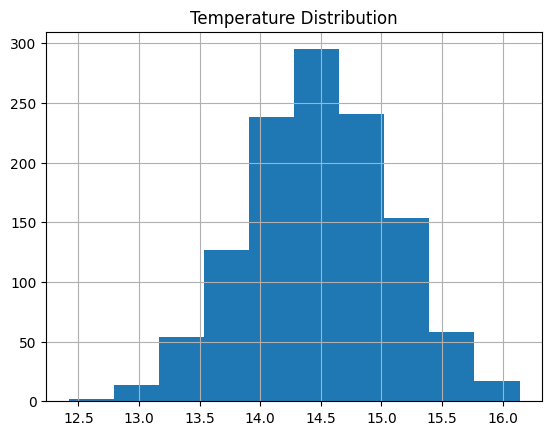

In [ ]:
df['global_avg_temperature'].hist()
plt.title("Temperature Distribution")
plt.show()

2. Rainfall Distribution

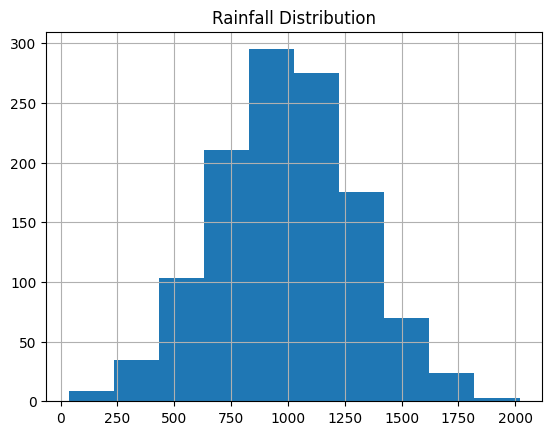

In [ ]:
df['annual_rainfall_mm'].hist()
plt.title("Rainfall Distribution")
plt.show()

3. AQI Distribution

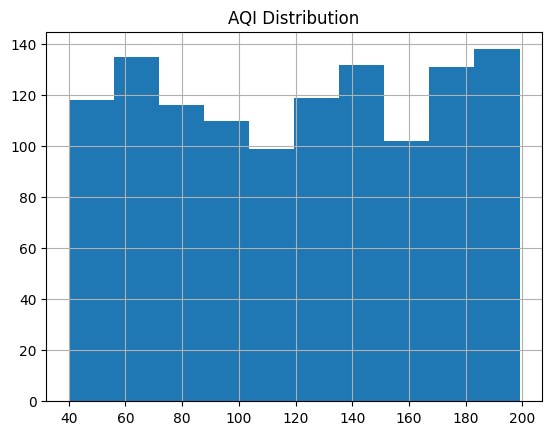

In [ ]:
df['air_quality_index'].hist()
plt.title("AQI Distribution")
plt.show()

4. Rainfall vs Temperature

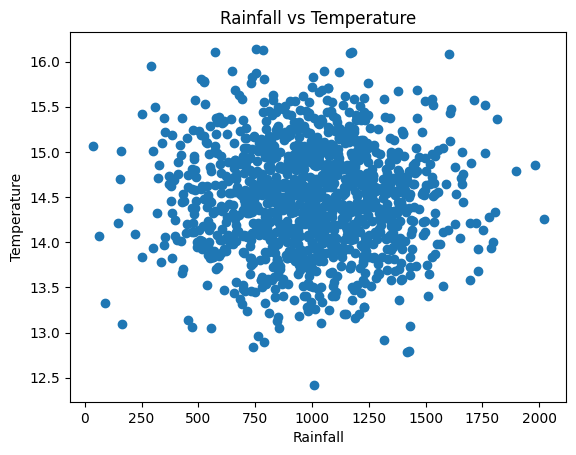

In [ ]:
plt.scatter(df['annual_rainfall_mm'], df['global_avg_temperature'])
plt.xlabel("Rainfall")
plt.ylabel("Temperature")
plt.title("Rainfall vs Temperature")
plt.show()

5. CO2 vs Temperature

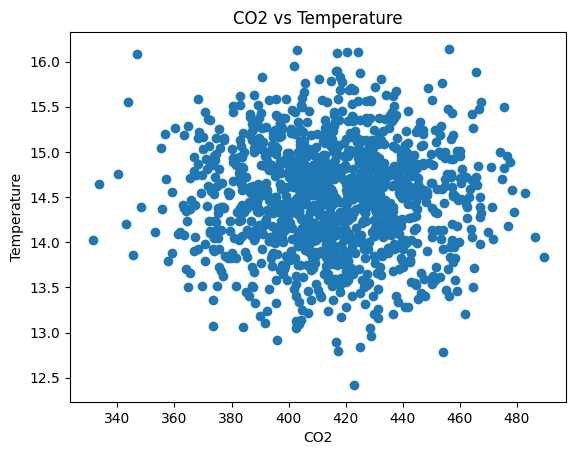

In [ ]:
plt.scatter(df['co2_concentration_ppm'], df['global_avg_temperature'])
plt.xlabel("CO2")
plt.ylabel("Temperature")
plt.title("CO2 vs Temperature")
plt.show()

6. Fossil Fuel vs AQI

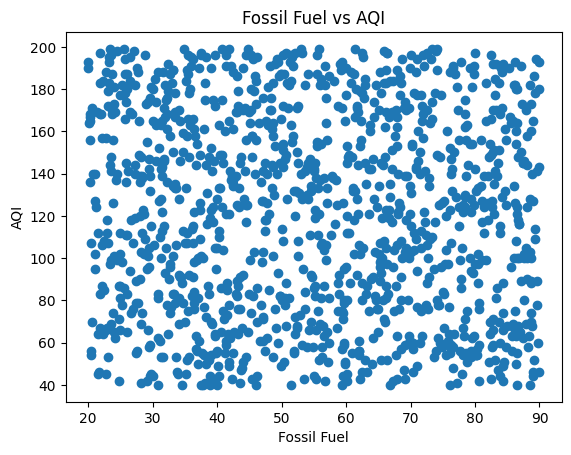

In [ ]:
plt.scatter(df['fossil_fuel_consumption'], df['air_quality_index'])
plt.xlabel("Fossil Fuel")
plt.ylabel("AQI")
plt.title("Fossil Fuel vs AQI")
plt.show()

7. Yearly Global Temperature Trend

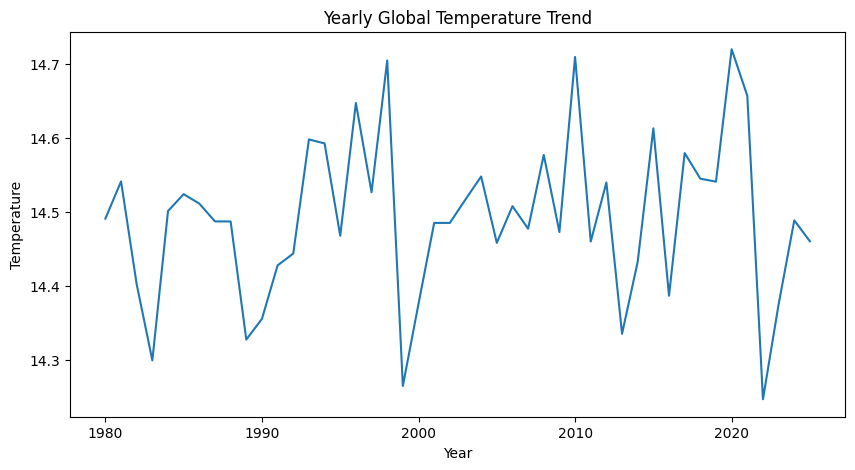

In [ ]:
temp_trend = df.groupby(df['year'].dt.year)['global_avg_temperature'].mean()

temp_trend.plot(figsize=(10,5))
plt.title("Yearly Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

8. Yearly Rainfall Trend

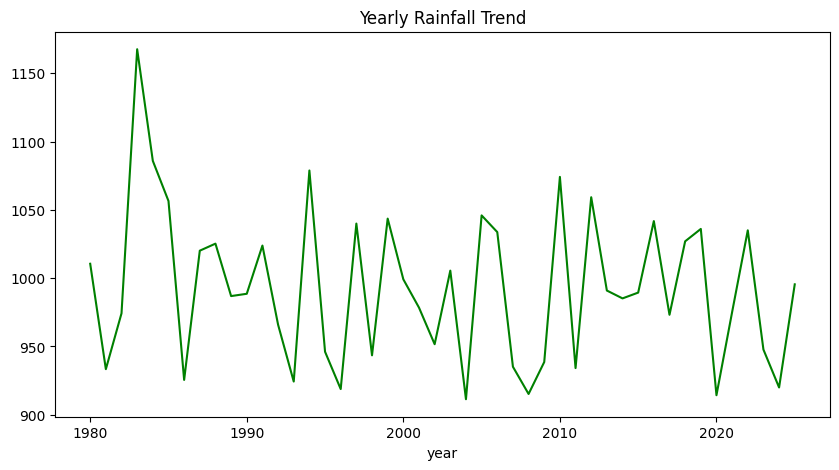

In [ ]:
rain_trend = df.groupby(df['year'].dt.year)['annual_rainfall_mm'].mean()

rain_trend.plot(figsize=(10,5), color='green')
plt.title("Yearly Rainfall Trend")
plt.show()

9. Yearly Air Quality Trend

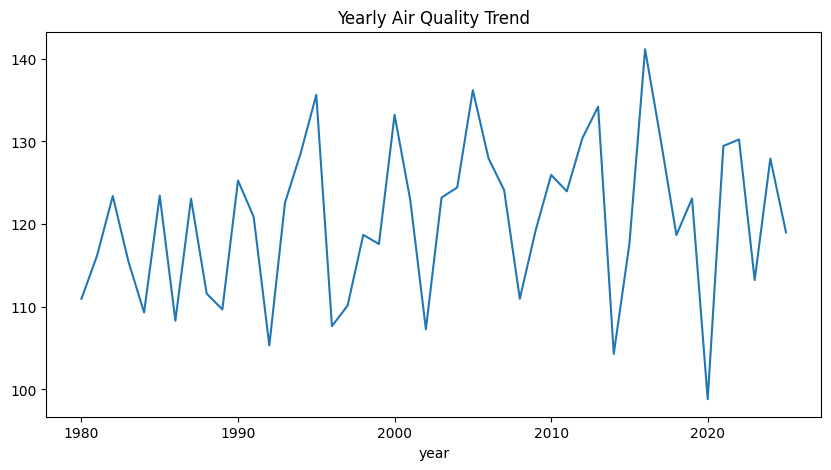

In [ ]:
air_trend = df.groupby(df['year'].dt.year)['air_quality_index'].mean()

air_trend.plot(figsize=(10,5))
plt.title("Yearly Air Quality Trend")
plt.show()

10. Correlation Heatmap

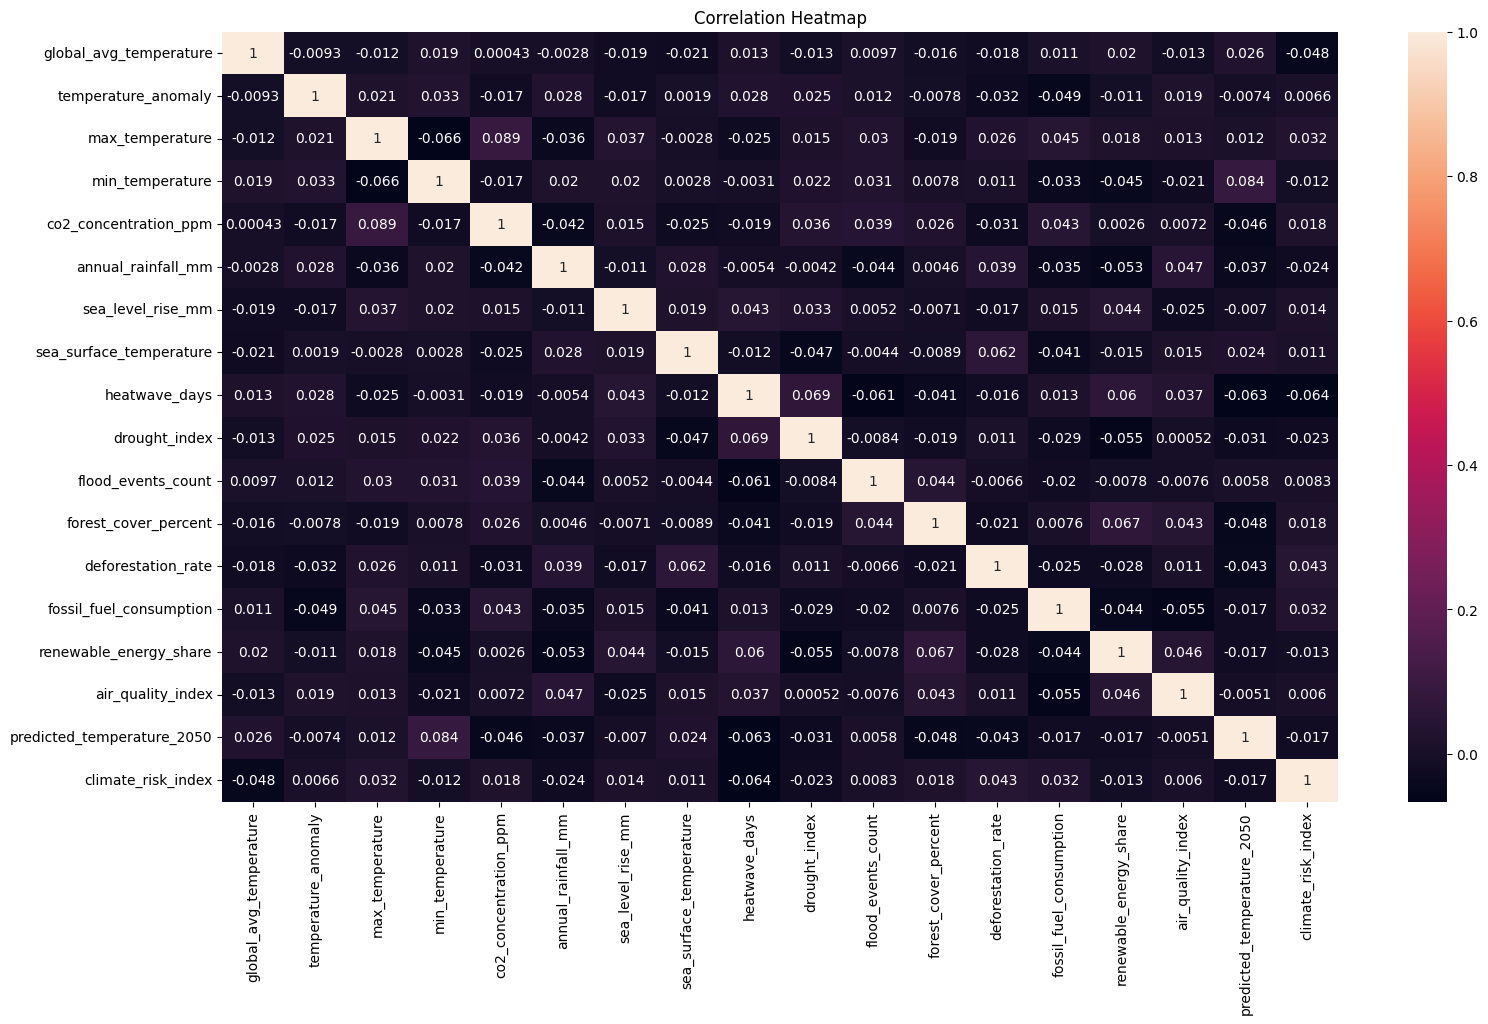

In [ ]:
import seaborn as sns

plt.figure(figsize=(18,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

11. Seasonal Trends

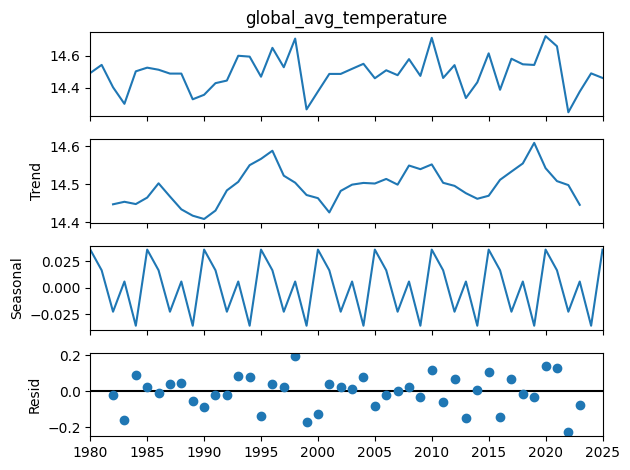

In [ ]:
temp_series = temp_trend

decomposition = seasonal_decompose(temp_series, model='additive', period=5)

decomposition.plot()
plt.show()

FEATURE ENGINEERING

In [ ]:
features = [
    'co2_concentration_ppm',
    'annual_rainfall_mm',
    'sea_level_rise_mm',
    'air_quality_index',
    'fossil_fuel_consumption',
    'renewable_energy_share'
]

**MACHINE LEARNING MODELS**

1. Temperature: Actual vs Predicted

🌡️ Temperature Model
MAE: 0.48068700000706566
R2 Score: -0.004075517896704239


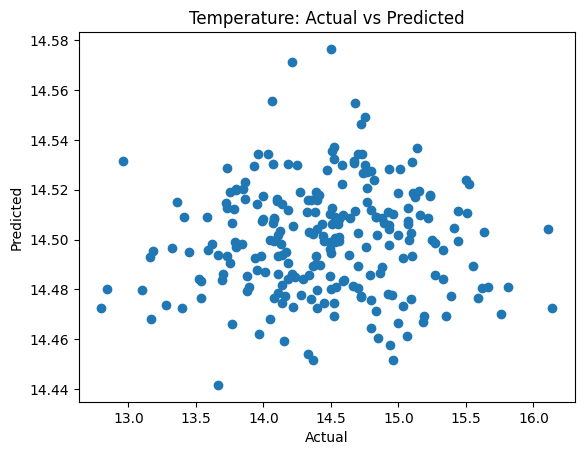

In [ ]:
X_temp = df[features]
y_temp = df['global_avg_temperature']

X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.2)

model_temp = LinearRegression()
model_temp.fit(X_train, y_train)

pred_temp = model_temp.predict(X_test)

print("🌡️ Temperature Model")
print("MAE:", mean_absolute_error(y_test, pred_temp))
print("R2 Score:", r2_score(y_test, pred_temp))

# Temperature
plt.scatter(y_test, pred_temp)
plt.title("Temperature: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

2. Rainfall: Actual vs Predicted


🌧️ Rainfall Model
MAE: 257.8180729915806
R2 Score: -0.03113060731160444


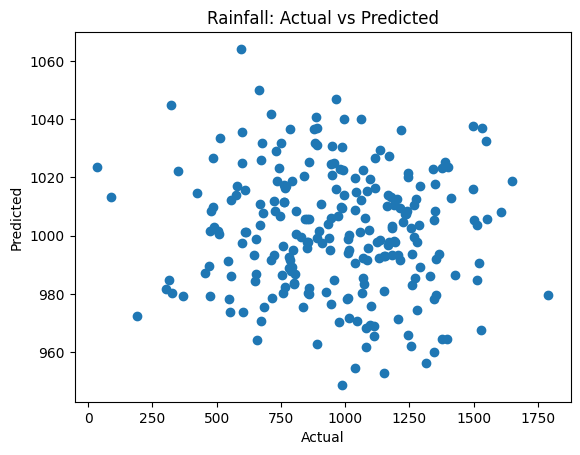

In [ ]:
X_rain = df[
    ['co2_concentration_ppm', 'global_avg_temperature', 'sea_level_rise_mm']
]
y_rain = df['annual_rainfall_mm']

X_train, X_test, y_train, y_test = train_test_split(X_rain, y_rain, test_size=0.2)

model_rain = LinearRegression()
model_rain.fit(X_train, y_train)

pred_rain = model_rain.predict(X_test)

print("\n🌧️ Rainfall Model")
print("MAE:", mean_absolute_error(y_test, pred_rain))
print("R2 Score:", r2_score(y_test, pred_rain))

# Rainfall
plt.scatter(y_test, pred_rain)
plt.title("Rainfall: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

3. AQI: Actual vs Predicted


🌫️ AQI Model
MAE: 42.6443436393449
R2 Score: 0.009516029594126008


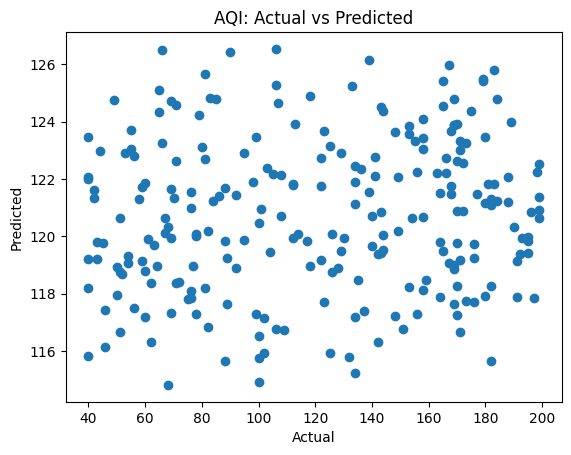

In [ ]:
X_aqi = df[
    ['co2_concentration_ppm', 'fossil_fuel_consumption', 'renewable_energy_share']
]
y_aqi = df['air_quality_index']

X_train, X_test, y_train, y_test = train_test_split(X_aqi, y_aqi, test_size=0.2)

model_aqi = LinearRegression()
model_aqi.fit(X_train, y_train)

pred_aqi = model_aqi.predict(X_test)

print("\n🌫️ AQI Model")
print("MAE:", mean_absolute_error(y_test, pred_aqi))
print("R2 Score:", r2_score(y_test, pred_aqi))

# AQI
plt.scatter(y_test, pred_aqi)
plt.title("AQI: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

**Time Series Analysis (Forecasting)**

1. Temperature Forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



🌡️ Next 5 Years Temperature Forecast:
2026    14.488795
2027    14.490404
2028    14.492023
2029    14.490851
2030    14.491991
Name: predicted_mean, dtype: float64


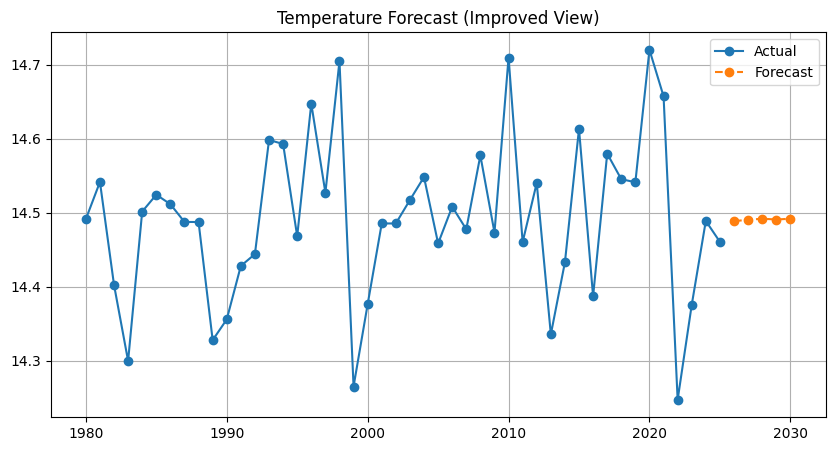

In [ ]:
# Prepare time series
temp_year = df.groupby("year")["global_avg_temperature"].mean()

# Convert index to datetime
temp_year.index = pd.to_datetime(temp_year.index, format="%Y")

# Model
model_temp = ARIMA(temp_year, order=(2,1,2))
model_temp_fit = model_temp.fit()

# Forecast
forecast_temp = model_temp_fit.forecast(steps=5)

# Convert index to only YEAR
forecast_temp.index = forecast_temp.index.year

print("\n🌡️ Next 5 Years Temperature Forecast:")
print(forecast_temp)


plt.figure(figsize=(10,5))

#Temperature  example
plt.plot(temp_year, marker='o', label="Actual")

# Generate a range of years for the forecast plot
forecast_years_temp = pd.date_range(start=temp_year.index[-1] + pd.DateOffset(years=1), periods=5, freq='YS')
plt.plot(
    forecast_years_temp,
    forecast_temp,
    marker='o',
    linestyle='--',
    label="Forecast"
)

plt.title("Temperature Forecast (Improved View)")
plt.legend()
plt.grid()

plt.show()

2. Rainfall Forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)



🌧️ Next 5 Years Rainfall Forecast:
2026    990.096351
2027    994.834464
2028    990.729950
2029    994.279004
2030    991.211152
Name: predicted_mean, dtype: float64


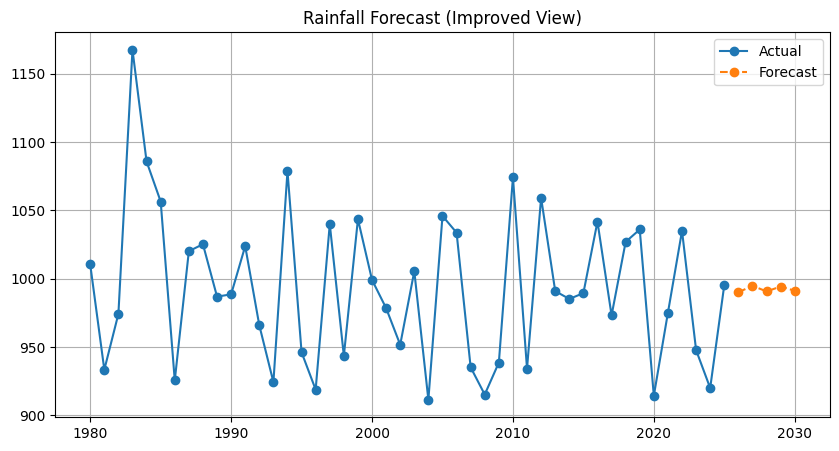

In [ ]:
rain_year = df.groupby("year")["annual_rainfall_mm"].mean()

rain_year.index = pd.to_datetime(rain_year.index, format="%Y")

model_rain = ARIMA(rain_year, order=(2,1,2))
model_rain_fit = model_rain.fit()

forecast_rain = model_rain_fit.forecast(steps=5)

# Convert index to only YEAR
forecast_rain.index = forecast_rain.index.year

print("\n🌧️ Next 5 Years Rainfall Forecast:")
print(forecast_rain)

plt.figure(figsize=(10,5))

# Rainfall example
plt.plot(rain_year, marker='o', label="Actual")

# Generate a range of years for the forecast plot
forecast_years_rain = pd.date_range(start=rain_year.index[-1] + pd.DateOffset(years=1), periods=5, freq='YS')
plt.plot(
    forecast_years_rain,
    forecast_rain,
    marker='o',
    linestyle='--',
    label="Forecast"
)

plt.title("Rainfall Forecast (Improved View)")
plt.legend()
plt.grid()

plt.show()

4. AQI Forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check


🌫️ Next 5 Years AQI Forecast:
2026    118.514177
2027    118.311268
2028    118.335088
2029    118.414516
2030    118.457812
Name: predicted_mean, dtype: float64


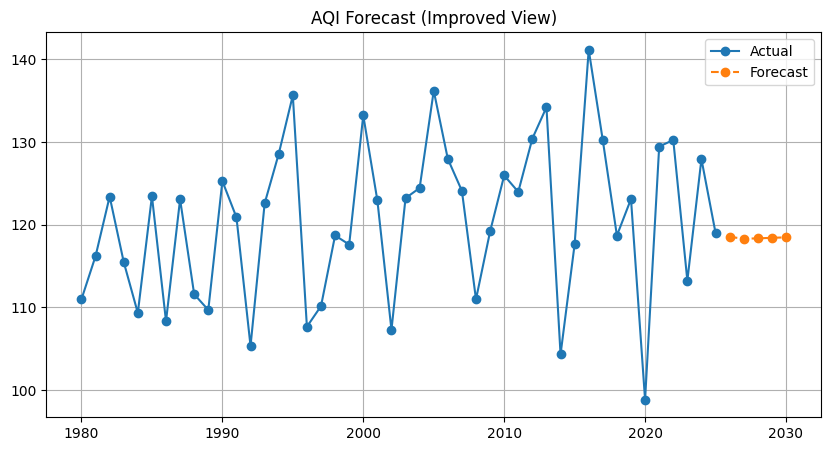

In [ ]:
aqi_year = df.groupby("year")["air_quality_index"].mean()

aqi_year.index = pd.to_datetime(aqi_year.index, format="%Y")

model_aqi = ARIMA(aqi_year, order=(2,1,2))
model_aqi_fit = model_aqi.fit()

forecast_aqi = model_aqi_fit.forecast(steps=5)

# Convert index to only YEAR
forecast_aqi.index = forecast_aqi.index.year

print("\n🌫️ Next 5 Years AQI Forecast:")
print(forecast_aqi)


plt.figure(figsize=(10,5))

# AQI example
plt.plot(aqi_year, marker='o', label="Actual")

# Generate a range of years for the forecast plot
forecast_years_aqi = pd.date_range(start=aqi_year.index[-1] + pd.DateOffset(years=1), periods=5, freq='YS')
plt.plot(
    forecast_years_aqi,
    forecast_aqi,
    marker='o',
    linestyle='--',
    label="Forecast"
)

plt.title("AQI Forecast (Improved View)")
plt.legend()
plt.grid()

plt.show()

**Deep Learning (LSTM)**

1. Data Preparation

In [ ]:
data = temp_year.values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
X_lstm = []
y_lstm = []

for i in range(5, len(data_scaled)):
    X_lstm.append(data_scaled[i-5:i])
    y_lstm.append(data_scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

In [ ]:
split = int(0.8 * len(X_lstm))

X_train_lstm = X_lstm[:split]
X_test_lstm = X_lstm[split:]

y_train_lstm = y_lstm[:split]
y_test_lstm = y_lstm[split:]

2. Model Architecture

In [ ]:
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(5,1)))
model_lstm.add(LSTM(50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3. Training

In [ ]:
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=8)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3050
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2086
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1309
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0720
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0613
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0691
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0629
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0535
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0559
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0556
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0547
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0543
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0533
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0531
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0535
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━━━━

4. Future Prediction (LSTM Model)

In [ ]:
predictions = model_lstm.predict(X_test_lstm)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step


In [ ]:
future_input = data_scaled[-5:]
future_input = future_input.reshape(1,5,1)

future_preds = []

for _ in range(10):
    pred = model_lstm.predict(future_input)[0][0]
    future_preds.append(pred)

    future_input = np.append(future_input[:,1:,:], [[[pred]]], axis=1)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))

print("Future Temperature:", future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Future Temperature: [[14.469188 ]
 [14.4443445]
 [14.469738 ]
 [14.480261 ]
 [14.477792 ]
 [14.47927  ]
 [14.480139 ]
 [14.48431  ]
 [14.4857   ]
 [14.4860525]]


5. LSTM Model Prediction Visualization

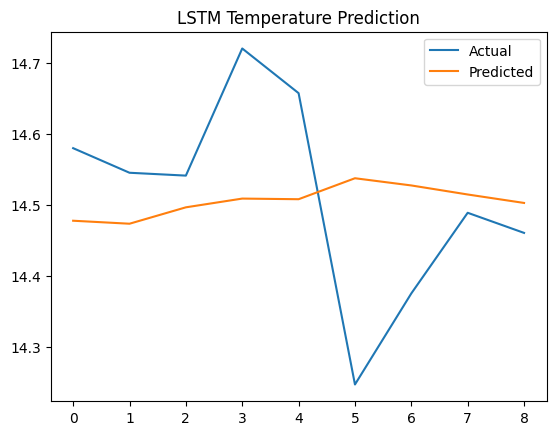

In [ ]:
plt.figure()
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("LSTM Temperature Prediction")
plt.show()